<font size=6>实验2：卷积神经网络</font>

# 实验简介

本实验介绍如何利用PyTorch搭建卷积神经网络，并基于卷积神经网络创建一个图像分类器。通过本实验，你将掌握以下技能：

- 对图像数据进行预处理
- 利用PyTorch搭建并训练简单的卷积神经网络
- 利用PyTorch从头开始搭建ResNet


# 实验环境准备

首先，你需要安装完成本实验所需的必要组件。

## 安装Miniconda

从以下链接下载Miniconda安装包并完成安装[[Link]](https://mirrors.tuna.tsinghua.edu.cn/anaconda/miniconda/Miniconda3-py310_24.1.2-0-Windows-x86_64.exe)，安装过程中需要选中`Register Anaconda as my default Python 3.10`。若计算机上已经安装好Miniconda或Anaconda，请跳过此步骤。

## 安装Jupyter Notebook

在Anaconda Prompt中执行`pip install notebook`，以安装Jupyter Notebook。

安装完成后，在Anaconda Prompt执行`jupyter notebook`，检查是否能够成功启动Notebook。

若计算机上已经安装好Jupyter Notebook，请跳过此步骤。

## 安装必要的Package

你可以使用以下代码在Jupyter Notebook中检查并安装必要的包，也可事先在Anaconda Prompt中通过`pip`或`conda`安装好。

In [1]:
from importlib.util import find_spec

# 检查numpy是否已安装
if find_spec('numpy').loader:
    print('numpy is available.')
else:
    !pip install numpy -i https://pypi.tuna.tsinghua.edu.cn/simple/

# 检查matplotlib是否已安装
if find_spec('matplotlib').loader:
    print('matplotlib is available.')
else:
    !pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple/

# 检查PIL是否已安装
if find_spec('PIL').loader:
    print('PIL is available.')
else:
    !pip install pillow -i https://pypi.tuna.tsinghua.edu.cn/simple/

# 检查PyTorch是否已安装
if find_spec('torch').loader:
    print('PyTorch is available.')
else:
    !pip install torch -i https://pypi.tuna.tsinghua.edu.cn/simple/
    
# 检查torchvision是否已安装
if find_spec('torchvision').loader:
    print('torchvision is available.')
else:
    !pip install torchvision -i https://pypi.tuna.tsinghua.edu.cn/simple/

# 检查torchsummary是否已安装
if find_spec('torchsummary').loader:
    print('torchsummary is available.')
else:
    !pip install torchsummary -i https://pypi.tuna.tsinghua.edu.cn/simple/

numpy is available.
matplotlib is available.
PIL is available.
PyTorch is available.
torchvision is available.
torchsummary is available.


当然，你可以选择在[Kaggle](https://www.kaggle.com/)等平台完成实验。在此类平台上，通常已经安装好了常用的包，无需再额外执行以上代码检查包的安装情况，且能够方便地加载各类数据集。

# CIFAR-10数据集简介

本实验将使用CIFAR-10图像分类数据集。不同于MNIST或FashionMNIST数据集的是，CIFAR-10数据集中的图片为RGB三通道彩色图片。每张图片的尺寸为32×32，共包含10个类别，每个类别有6000张图片，共有50000张训练图片和10000张测试图片。

# 下载并查看数据

我们使用`torchvision`获取CIFAR-10数据集，并创建数据加载器（DataLoader）。此外，为了方便PyTorch进行处理，首先使用`torchvision`自带的数据转换器模块对图片进行适当的预处理。

In [ ]:
# 防止可能的kmp_duplicate_lib_ok错误
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms 

## 下载数据

CIFAR-10的官方下载地址为[[Link]](http://www.cs.toronto.edu/~kriz/cifar.html)，但下载速度较慢。你可以使用以下链接更快地完成数据集下载。

- [[微云]](https://share.weiyun.com/56FKfYz)，文件提取码：nwdmtc，在当前Jupyter Notebook文件所在的目录下，创建一个`dataset`目录，并将下载得到的文件（无需解压）放置在`dataset`目录；
- [[天池]](https://tianchi.aliyun.com/dataset/92100)，下载`Cifar10.zip`文件，将其解压，在当前Jupyter Notebook文件所在的目录下，创建一个`dataset`目录，在刚才解压的目录中找到`cifar-10-batches-py`文件夹，并复制到`datase`目录。

如果你选择在天池、Kaggle等平台完成实验，则不需要将数据下载到本地，而是直接挂载相应数据集即可。

## 定义数据转换操作

利用`torchvision`创建的数据集为PILImage图像，每个像素的取值范围为`[0, 1]`，我们定义一个转换器，用于将图片转换为张量（Tensor），并将每个像素的取值范围标准化为`[-1, 1]`。

`transforms.Compose`能够定义一组数据的预处理操作，例如这里定义了转换为张量以及标准化两个预处理操作，将其应用到数据集时，将按顺序执行此处定义的处理。

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

## 定义数据集和数据加载器

以下代码会对下载的数据集自动进行解压。请按需修改`root`参数。

In [5]:
batch_size = 4

# 创建CIFAR10数据集的训练集，并创建训练集数据加载器
trainset = torchvision.datasets.CIFAR10(root='./dataset', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

# 创建CIFAR10数据集的测试集，并创建测试集数据加载器
testset = torchvision.datasets.CIFAR10(root='./dataset', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


定义类别标签。

In [8]:
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

## 查看数据

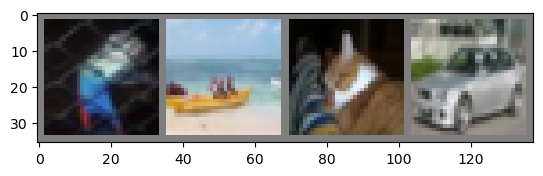

bird  ship  cat   car  


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


def imshow(img):
    img = img / 2 + 0.5  # 将像素值重新映射到[0, 1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # 将数据维度由(3, 32, 32)变更为(32, 32, 3)
    plt.show()


dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

# 定义卷积神经网络模型

接下来，定义卷积神经网络拓扑结构、损失函数及优化方法。

## 定义卷积神经网络拓扑结构

在`torch.nn`模块中，提供了`Conv2d`、`MaxPool2d`等卷积神经网络常用的模块，因此，我们可以利用PyTorch方便地搭建卷积神经网络。

请检查神经网络中每层的输入、输出维度，以避免创建无效的神经网络配置。

In [10]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # 在通过全连接层之前，先将数据进行展平（batch除外）
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

> **练习：请绘制上面的代码块所定义的神经网络拓扑结构。**

## 定义损失函数及优化器

使用交叉熵损失，并采用含动量的随机梯度下降算法。

In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# 训练模型

训练模型通常按照以下顺序组织代码：

- 确定要遍历数据集的次数（即epoch）；
- 每次迭代，利用DataLoader加载数据；
- 重置梯度（防止梯度累加）；
- 前向传播；
- 计算损失函数值；
- 反向传播；
- 利用优化器进行参数更新。

In [14]:
for epoch in range(2):  # 为减少执行时间，这里仅遍历2次

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # data是一个列表，形如 [inputs, labels]
        inputs, labels = data

        # 将梯度置零
        optimizer.zero_grad()

        # 前向传播
        outputs = net(inputs)
        
        # 计算损失
        loss = criterion(outputs, labels)
        
        # 反向传播
        loss.backward()
        
        # 利用优化器进行参数更新
        optimizer.step()

        # 输出训练日志
        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'Epoch: {epoch + 1}, batch: {i + 1:5d}, loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('训练结束！')

Epoch: 1, batch:  2000, loss: 1.426
Epoch: 1, batch:  4000, loss: 1.407
Epoch: 1, batch:  6000, loss: 1.363
Epoch: 1, batch:  8000, loss: 1.334
Epoch: 1, batch: 10000, loss: 1.309
Epoch: 1, batch: 12000, loss: 1.297
Epoch: 2, batch:  2000, loss: 1.228
Epoch: 2, batch:  4000, loss: 1.251
Epoch: 2, batch:  6000, loss: 1.234
Epoch: 2, batch:  8000, loss: 1.174
Epoch: 2, batch: 10000, loss: 1.185
Epoch: 2, batch: 12000, loss: 1.146
训练结束！


可使用`torch.save`将训练好的模型权重存储到磁盘。

In [15]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

# 测试模型效果

我们已经在训练数据集上遍历2次，可以观察到模型损失逐步下降。但是，我们需要在训练结束后，在测试集上检查模型的效果和泛化能力。

首先，我们从测试集中取出几张图片，并查看其真实分类标签。

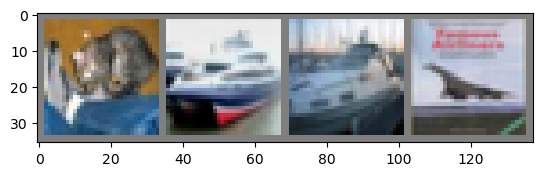

GroundTruth:  cat   ship  ship  plane


In [16]:
dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

如果你希望加载保存的模型，可执行以下代码。

In [17]:
net = Net()
net.load_state_dict(torch.load(PATH))

<All keys matched successfully>

检查神经网络模型输出。

In [19]:
outputs = net(images)
_, predicted = torch.max(outputs, 1)
print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  cat   ship  plane plane


上述测试结果取决于你的模型训练情况，但一般至少能够在1张图片上获得正确结果。接下来，我们进一步检查模型在整个测试数据集上的表现。

In [20]:
correct = 0
total = 0

# 在测试阶段，我们不需要计算梯度，因此此处关闭梯度计算
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        # 直观地，我们取“能量”值最高的类别作为最终的预测类别
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'模型在测试集的准确率为: {100 * correct // total} %')

模型在测试集的准确率为: 58 %


一般而言，你得到的准确率在50-60%之间。相较随机猜测（准确率为10%）而言，我们的模型已经具备一定可用性，但显然准确率不是很高。

如果你希望进一步检查在每个类别上的分类准确率，可执行以下代码块。

In [21]:
# 准备用于记录各类别正确分类数及总数的Dict
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# 测试模式，无需计算梯度
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # 对于每个类别，检查有多少样本能够正确分类
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# 计算并输出各类别的准确率
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'类别 {classname:5s} 的准确率为： {accuracy:.1f} %')

类别 plane 的准确率为： 70.3 %
类别 car   的准确率为： 72.4 %
类别 bird  的准确率为： 52.1 %
类别 cat   的准确率为： 42.3 %
类别 deer  的准确率为： 51.4 %
类别 dog   的准确率为： 40.6 %
类别 frog  的准确率为： 60.5 %
类别 horse 的准确率为： 71.3 %
类别 ship  的准确率为： 59.8 %
类别 truck 的准确率为： 63.8 %


# 模型改进

从模型测试效果中可以看出，刚才我们构建的卷积神经网络模型无法达到很高的分类准确率。我们猜想，其原因可能是训练时间太短，也可能是模型太过简单。

> **练习：尝试增加上述模型的训练epoch数量，观察能否提高准确率。**

这里，我们使用ResNet-18作为特征提取网络，提升CIFAR10图片分类器的性能。

## 搭建ResNet模型

首先，我们定义ResNet的基本结构——ResBlock。

In [75]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        # 为了提高通用性，我们将输入通道数、输出通道数、步长等设置为参数
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 如果输入输出维度不等，通过1×1卷积改变维度
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        residual = self.shortcut(x)
        out += residual
        out = torch.relu(out)
        return out

In [76]:
res_block = ResidualBlock(16, 64)
print(res_block)

x = torch.randn(2, 16, 32, 32)
y = res_block(x)
print(y.shape)

ResidualBlock(
  (conv1): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut): Sequential(
    (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)
torch.Size([2, 64, 32, 32])


接下来，定义ResNet网络结构。

In [79]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 16
        self.conv = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self.make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self.make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self.make_layer(block, 64, num_blocks[2], stride=2)
        self.layer4 = self.make_layer(block, 128, num_blocks[3], stride=2)
        self.avg_pool = nn.AvgPool2d(kernel_size=4)
        self.fc = nn.Linear(128, num_classes)

    def make_layer(self, block, out_channels, num_blocks, stride=1):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

实例化ResNet模型。

In [80]:
from torchsummary import summary

resnet = ResNet(ResidualBlock, [2, 2, 2, 2])
summary(resnet, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             432
       BatchNorm2d-2           [-1, 16, 32, 32]              32
              ReLU-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 16, 32, 32]           2,304
       BatchNorm2d-5           [-1, 16, 32, 32]              32
              ReLU-6           [-1, 16, 32, 32]               0
            Conv2d-7           [-1, 16, 32, 32]           2,304
       BatchNorm2d-8           [-1, 16, 32, 32]              32
     ResidualBlock-9           [-1, 16, 32, 32]               0
           Conv2d-10           [-1, 16, 32, 32]           2,304
      BatchNorm2d-11           [-1, 16, 32, 32]              32
             ReLU-12           [-1, 16, 32, 32]               0
           Conv2d-13           [-1, 16, 32, 32]           2,304
      BatchNorm2d-14           [-1, 16,

## 损失函数及优化器

使用交叉熵损失函数及带动量的SGD优化器。

In [90]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)

## 训练模型

由于模型更加复杂，模型训练的时间也相应增长。在无GPU的环境下，执行完以下代码通常需要15分钟左右，可以根据实际情况调整epoch等训练超参数。例如，你可以将epoch设置为5，但改变超参可能影响最终模型的准确率。

> **思考：batch_size对收敛速度是否有影响？为什么？**

In [91]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)

for epoch in range(10):  # 为减少执行时间，这里仅遍历10次

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # data是一个列表，形如 [inputs, labels]
        inputs, labels = data

        # 将梯度置零
        optimizer.zero_grad()

        # 前向传播
        outputs = resnet(inputs)
        
        # 计算损失
        loss = criterion(outputs, labels)
        
        # 反向传播
        loss.backward()
        
        # 利用优化器进行参数更新
        optimizer.step()

        # 输出训练日志
        running_loss += loss.item()
        if i % 100 == 99:
            print(f'Epoch: {epoch + 1}, batch: {i + 1:5d}, loss: {running_loss / 100:.3f}')
            running_loss = 0.0

print('训练结束！')

Epoch: 1, batch:   100, loss: 2.312
Epoch: 1, batch:   200, loss: 2.290
Epoch: 1, batch:   300, loss: 2.302
Epoch: 1, batch:   400, loss: 2.304
Epoch: 1, batch:   500, loss: 2.303
Epoch: 1, batch:   600, loss: 2.284
Epoch: 1, batch:   700, loss: 2.162
Epoch: 1, batch:   800, loss: 2.083
Epoch: 1, batch:   900, loss: 2.039
Epoch: 1, batch:  1000, loss: 1.961
Epoch: 1, batch:  1100, loss: 1.931
Epoch: 1, batch:  1200, loss: 1.927
Epoch: 1, batch:  1300, loss: 1.970
Epoch: 1, batch:  1400, loss: 1.908
Epoch: 1, batch:  1500, loss: 1.845
Epoch: 2, batch:   100, loss: 1.736
Epoch: 2, batch:   200, loss: 1.735
Epoch: 2, batch:   300, loss: 1.737
Epoch: 2, batch:   400, loss: 1.701
Epoch: 2, batch:   500, loss: 1.670
Epoch: 2, batch:   600, loss: 1.632
Epoch: 2, batch:   700, loss: 1.636
Epoch: 2, batch:   800, loss: 1.629
Epoch: 2, batch:   900, loss: 1.579
Epoch: 2, batch:  1000, loss: 1.592
Epoch: 2, batch:  1100, loss: 1.551
Epoch: 2, batch:  1200, loss: 1.514
Epoch: 2, batch:  1300, loss

## 测试模型效果

In [92]:
correct = 0
total = 0

# 由于ResNet使用了批正则化，测试阶段应将其关闭，故需使用eval()
resnet.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'模型在测试集的准确率为: {100 * correct // total} %')

模型在测试集的准确率为: 72 %


一般而言，模型经过大约10个epoch的训练，准确率就可以达到70%以上，大大超过了实验开始阶段搭建的简易模型。

In [93]:
# 保存模型权重
PATH = './resnet18.pth'
torch.save(resnet.state_dict(), PATH)

# 使用数据集外的图片进行测试

最后，你可以将模型应用于其他图片，例如你的手机相册中的图片或互联网图片。

> **探索：更换几张与本实验手册不同的图片，测试分类效果。**

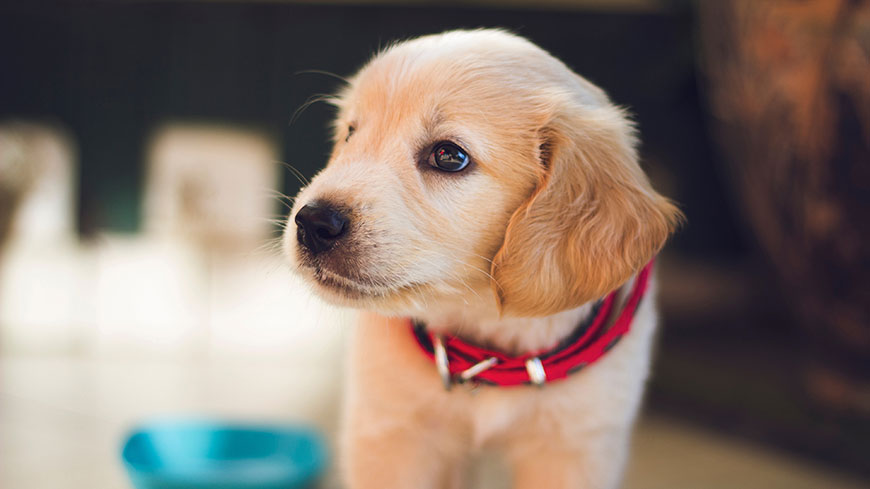

In [131]:
from PIL import Image
import numpy as np
import requests
 
classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')
PATH = './resnet18.pth'

model = ResNet(ResidualBlock, [2, 2, 2, 2])
model.load_state_dict(torch.load(PATH))  # 加载模型权重
model.eval()

# 读取要预测的图片
url = 'https://q5.itc.cn/q_70/images03/20250620/7911ae1bf1b246cb8b835a52c272f250.jpeg'
response = requests.get(url, stream=True)
img = Image.open(response.raw)  # 读取图像
img

In [132]:
transform = transforms.Compose(
    [transforms.Resize(32),
     transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

img1 = transform(img)

# 为图片增加一个batch_size维度
img1 = img1.unsqueeze(0)

output = model(img1)
prob = F.softmax(output, dim=1)
value, predicted = torch.max(output.data, 1)
print('Predicted: ', classes[predicted])

Predicted:  dog


> **探索：尝试修改代码，在GPU上完成模型训练和推理。**